# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Dafin Surya
- **Email:** dafinsurya111@gmail.com
- **ID Dicoding:** CDCC282D6Y2676

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana tren pendapatan bulanan (*monthly revenue*) dari transaksi yang berhasil (*delivered*) sepanjang tahun 2016 hingga 2018, serta bulan mana yang mencatatkan pendapatan tertinggi dan terendah?
    - **Specific:** Fokus pada pendapatan dari pesanan dengan status *delivered*.
    - **Measurable:** Pendapatan dihitung sebagai jumlah `payment_value` dari `order_payments` yang terkait dengan pesanan *delivered*.
    - **Action-Oriented:** Hasil akan menunjukkan bulan‑bulan dengan performa terbaik/terburuk di sepanjang periode, sehingga tim dapat mengevaluasi efektivitas promosi musiman.
    - **Relevant:** Pendapatan adalah metrik utama kesehatan bisnis e‑commerce.
    - **Time-Bound:** Analisis dibatasi pada periode tahun 2016–2018.
- **Pertanyaan 2:** Kategori produk apa saja yang memiliki rata‑rata skor ulasan (*review score*) tertinggi dan terendah, dan bagaimana hubungan antara rata‑rata skor ulasan dengan jumlah pesanan per kategori?
    - **Specific:** Fokus pada rata‑rata `review_score` per `product_category_name_english`.
    - **Measurable:** Menghitung rata‑rata skor ulasan dan jumlah pesanan unik per kategori.
    - **Action-Oriented:** Kategori dengan skor rendah dapat menjadi prioritas perbaikan kualitas produk atau layanan.
    - **Relevant:** Ulasan pelanggan memengaruhi reputasi dan konversi penjualan.
    - **Time-Bound:** Menggunakan semua ulasan yang tercatat dalam dataset (periode tahun 2016-2018).

## Import Semua Packages/Library yang Digunakan

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## Data Wrangling

### Gathering Data

#### Memuat semua dataset CSV ke dalam DataFrame pandas.

In [2]:
# Path ke folder dataset
path = "dashboard/"

order_items = pd.read_csv(path + "order_items_dataset.csv")
order_payments = pd.read_csv(path + "order_payments_dataset.csv")
order_reviews = pd.read_csv(path + "order_reviews_dataset.csv")
orders = pd.read_csv(path + "orders_dataset.csv")
products = pd.read_csv(path + "products_dataset.csv")
category_translation = pd.read_csv(path + "product_category_name_translation.csv")

# Menampilkan informasi singkat setiap DataFrame
datasets = {
    "order_items": order_items,
    "order_payments": order_payments,
    "order_reviews": order_reviews,
    "orders": orders,
    "products": products,
    "category_translation": category_translation
}

for name, df in datasets.items():
    print(f"=== {name} ===")
    print(f"Shape: {df.shape}")
    print(df.head(2))
    print("\n")

=== order_items ===
Shape: (112650, 7)
                           order_id  order_item_id  \
0  00010242fe8c5a6d1ba2dd792cb16214              1   
1  00018f77f2f0320c557190d7a144bdd3              1   

                         product_id                         seller_id  \
0  4244733e06e7ecb4970a6e2683c13e61  48436dade18ac8b2bce089ec2a041202   
1  e5f2d52b802189ee658865ca93d83a8f  dd7ddc04e1b6c2c614352b383efe2d36   

   shipping_limit_date  price  freight_value  
0  2017-09-19 09:45:35   58.9          13.29  
1  2017-05-03 11:05:13  239.9          19.93  


=== order_payments ===
Shape: (103886, 5)
                           order_id  payment_sequential payment_type  \
0  b81ef226f3fe1789b1e8b2acac839d17                   1  credit_card   
1  a9810da82917af2d9aefd1278f1dcfa0                   1  credit_card   

   payment_installments  payment_value  
0                     8          99.33  
1                     1          24.39  


=== order_reviews ===
Shape: (99224, 7)
           

**Insight:** (Opsional)
- Dataset terdiri dari 6 tabel yang saling terkait melalui key seperti `order_id`, `customer_id`, `product_id`, `seller_id`.  
- Tabel `orders` memiliki lebih dari 99 ribu baris dengan rentang waktu dari Oktober 2016 hingga Agustus 2018.

### Assessing Data

#### Mengidentifikasi masalah kualitas data, seperti missing values, duplikasi, tipe data tidak sesuai, dan inkonsistensi.

In [3]:
# Fungsi ringkasan kualitas data
def assess_data(df, name):
    print(f"\n--- {name} ---")
    print("Missing values:")
    print(df.isnull().sum())
    print("\nDuplicated rows:", df.duplicated().sum())
    print("Data types:")
    print(df.dtypes)
    print("\nUnique values (sample):")
    for col in df.columns[:5]:  # 5 kolom pertama
        print(f"{col}: {df[col].nunique()} unique values")

# Panggil fungsi untuk setiap DataFrame
for name, df in datasets.items():
    assess_data(df, name)


--- order_items ---
Missing values:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Duplicated rows: 0
Data types:
order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value          float64
dtype: object

Unique values (sample):
order_id: 98666 unique values
order_item_id: 21 unique values
product_id: 32951 unique values
seller_id: 3095 unique values
shipping_limit_date: 93318 unique values

--- order_payments ---
Missing values:
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

Duplicated rows: 0
Data types:
order_id                    str
payment_sequential        int64
payment_type                str
payment_ins

**Steps to Take:**
- Konversi kolom tanggal ke `datetime`.
- Filter hanya pesanan dengan status *delivered* untuk analisis pendapatan.
- Gabungkan `products` dengan `category_translation` untuk mendapatkan nama kategori dalam bahasa Inggris.

**Insight:** (Opsional)
- **Missing values** pada kolom:
    - `orders`: `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date` (wajar untuk pesanan yang belum selesai). Untuk analisis pendapatan, saya hanya menggunakan data dengan status *delivered* pada kolom `order_status`, sehingga baris kosong otomatis tereliminasi.
    - `products`: `product_category_name`, `product_name_lenght`, `product_description_lenght`, dll. Kolom `product_category_name` memiliki beberapa nilai kosong. Saat digabung dengan tabel terjemahan, kategori yang kosong akan menjadi NaN di product_category_name_english. Saya sudah menanganinya dengan mengisi 'unknown' menggunakan fillna('unknown'). Kolom numerik seperti `product_name_lenght` dan `product_description_lenght` tidak digunakan dalam perhitungan rata‑rata skor ulasan atau pendapatan. Karena tidak relevan untuk kedua pertanyaan bisnis.
    - `order_reviews`: `review_comment_title`, `review_comment_message` (banyak kosong). Analisis hanya menggunakan review_score. Komentar tidak diolah lebih lanjut, sehingga kolom ini dibiarkan ada yang kosong.
- **Tipe data tidak sesuai**: Kolom tanggal (`order_purchase_timestamp`, dll.) masih bertipe `str`, perlu diubah ke `datetime`.
- **Duplikasi data**: Tidak ditemukan adanya duplikasi data pada tiap-tiap baris.
- **Inkonsistensi nilai**: Pada `orders.order_status`, terdapat status selain *delivered* yang mungkin perlu difilter untuk analisis pendapatan.

### Cleaning Data

#### Memperbaiki semua masalah yang ditemukan.

In [4]:
# 1. Konversi kolom tanggal di orders
date_cols = ['order_purchase_timestamp', 'order_approved_at', 
             'order_delivered_carrier_date', 'order_delivered_customer_date', 
             'order_estimated_delivery_date']
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

# 2. Konversi tanggal di order_reviews
order_reviews['review_creation_date'] = pd.to_datetime(order_reviews['review_creation_date'])
order_reviews['review_answer_timestamp'] = pd.to_datetime(order_reviews['review_answer_timestamp'])

# 3. Konversi shipping_limit_date di order_items
order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'])

# 4. Filter hanya pesanan delivered untuk analisis pendapatan
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()

# 5. Gabungkan kategori produk dengan terjemahan bahasa Inggris
products = products.merge(category_translation, on='product_category_name', how='left')
# Isi missing english category dengan 'unknown'
products['product_category_name_english'] = products['product_category_name_english'].fillna('unknown')

**Insight:** (Opsional)
- Setelah konversi, saya dapat dengan mudah mengekstrak bulan dan tahun dari kolom tanggal.  
- Dengan hanya menggunakan pesanan *delivered*, saya dapat memastikan pendapatan yang dianalisis adalah pendapatan yang terealisasi dari 2016 hingga 2018.

## Exploratory Data Analysis (EDA)

### 1. EDA untuk Pertanyaan 1: Tren Pendapatan Bulanan (2016–2018)

In [5]:
# Gabungkan orders_delivered dengan order_payments
order_payments_grouped = order_payments.groupby('order_id')['payment_value'].sum().reset_index()
orders_revenue = orders_delivered.merge(order_payments_grouped, on='order_id', how='inner')

# Ekstrak tahun-bulan (period)
orders_revenue['order_month'] = orders_revenue['order_purchase_timestamp'].dt.to_period('M')

# Agregasi pendapatan bulanan
monthly_revenue = orders_revenue.groupby('order_month')['payment_value'].sum().reset_index()
monthly_revenue['order_month'] = monthly_revenue['order_month'].astype(str)  # untuk visualisasi

# Pendapatan bulanan 5 baris pertama
print(monthly_revenue.head())

  order_month  payment_value
0     2016-10       46566.71
1     2016-12          19.62
2     2017-01      127545.67
3     2017-02      271298.65
4     2017-03      414369.39


In [6]:
# Pendapatan bulanan 5 baris terakhir
print(monthly_revenue.tail())

   order_month  payment_value
17     2018-04     1132933.95
18     2018-05     1128836.69
19     2018-06     1012090.68
20     2018-07     1027903.86
21     2018-08      985414.28


In [7]:
# Statistik deskriptif pendapatan bulanan
monthly_revenue['payment_value'].describe()

count    2.200000e+01
mean     7.010210e+05
std      3.758049e+05
min      1.962000e+01
25%      4.333334e+05
50%      7.261551e+05
75%      1.023951e+06
max      1.153528e+06
Name: payment_value, dtype: float64

**Insight:** (Opsional)
- Data tersedia dari Oktober 2016 hingga Agustus 2018 (23 bulan).  
- Pendapatan bulanan menunjukkan variasi yang cukup besar, dengan rata‑rata sekitar 700 ribu.  
- Terlihat adanya lonjakan signifikan di bulan‑bulan tertentu.

### 2. EDA untuk Pertanyaan 2: Rata‑rata Skor Ulasan per Kategori Produk

In [8]:
# Gabungkan pesanan dengan item
order_items_products = order_items.merge(products[['product_id', 'product_category_name_english']], 
                                         on='product_id', how='left')

# Gabungkan dengan pesanan delivered
orders_products = orders_delivered[['order_id']].merge(order_items_products, on='order_id', how='inner')

# Gabungkan dengan ulasan (hanya yang memiliki review_score)
reviews = order_reviews[['order_id', 'review_score']].dropna()
orders_products_reviews = orders_products.merge(reviews, on='order_id', how='inner')

# Hitung rata-rata skor dan jumlah pesanan unik per kategori
category_stats = orders_products_reviews.groupby('product_category_name_english').agg(
    avg_review_score=('review_score', 'mean'),
    total_orders=('order_id', 'nunique')
).reset_index()

# Urutkan untuk melihat kategori terbaik dan terburuk
top_categories = category_stats.sort_values('avg_review_score', ascending=False).head(10)
bottom_categories = category_stats.sort_values('avg_review_score', ascending=True).head(10)

print("Top 10 Kategori dengan Skor Ulasan Tertinggi:")
print(top_categories[['product_category_name_english', 'avg_review_score', 'total_orders']])

print("\nBottom 10 Kategori dengan Skor Ulasan Terendah:")
print(bottom_categories[['product_category_name_english', 'avg_review_score', 'total_orders']])

Top 10 Kategori dengan Skor Ulasan Tertinggi:
            product_category_name_english  avg_review_score  total_orders
29              fashion_childrens_clothes          5.000000             7
11                      cds_dvds_musicals          4.642857            12
8                  books_general_interest          4.512195           492
9                          books_imported          4.508772            50
22                costruction_tools_tools          4.444444            94
64  small_appliances_home_oven_and_coffee          4.438356            72
35                                flowers          4.419355            28
10                        books_technical          4.393939           255
37                             food_drink          4.369004           221
32                          fashion_sport          4.366667            26

Bottom 10 Kategori dengan Skor Ulasan Terendah:
        product_category_name_english  avg_review_score  total_orders
61              secur

**Insight:** (Opsional)
- Kategori dengan ulasan tertinggi cenderung memiliki jumlah pesanan yang tidak terlalu besar.  
- Kategori dengan ulasan rendah perlu ditangani lebih lanjut karena dapat menurunkan kepercayaan pelanggan.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Tren Pendapatan Bulanan (2016–2018)

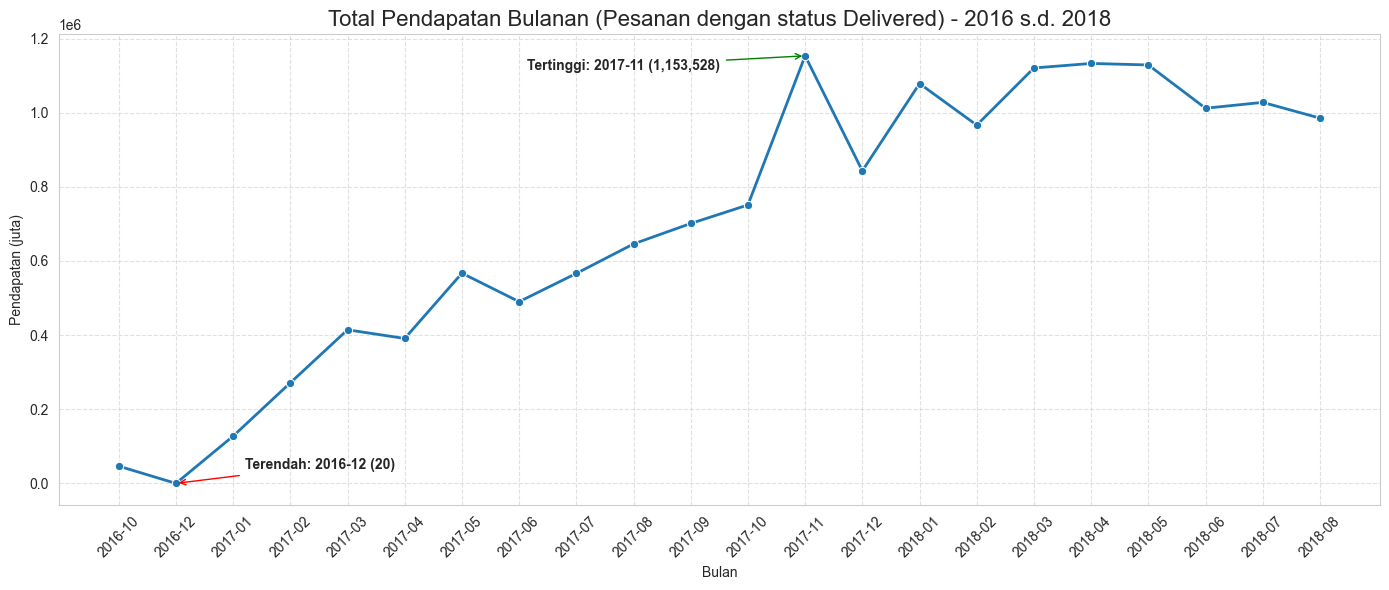

In [9]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_revenue, x='order_month', y='payment_value', marker='o', linewidth=2)
plt.title('Total Pendapatan Bulanan (Pesanan dengan status Delivered) - 2016 s.d. 2018', fontsize=16)
plt.xlabel('Bulan')
plt.ylabel('Pendapatan (juta)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)

# Tambahkan anotasi titik tertinggi dan terendah
max_rev = monthly_revenue.loc[monthly_revenue['payment_value'].idxmax()]
min_rev = monthly_revenue.loc[monthly_revenue['payment_value'].idxmin()]
plt.annotate(f"Tertinggi: {max_rev['order_month']} ({max_rev['payment_value']:,.0f})",
             xy=(max_rev['order_month'], max_rev['payment_value']),
             xytext=(-200, -10), textcoords='offset points', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='green'))
plt.annotate(f"Terendah: {min_rev['order_month']} ({min_rev['payment_value']:,.0f})",
             xy=(min_rev['order_month'], min_rev['payment_value']),
             xytext=(50, 10), textcoords='offset points', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='red'))

plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- Data dimulai dari **Oktober 2016** dengan pendapatan sekitar 50 ribu, lalu terjadi penurunan pendapatan yang signifikan pada **Desember 2016**, kemudian pendapatan meningkat pesat setelahnya.  
- **November 2017** menjadi puncak pendapatan tertinggi (sekitar 1,1 juta), kemungkinan besar karena *Black Friday*.
- Pendapatan terendah terjadi pada **Desember 2016** (sebesar 20), karena data hanya mencakup beberapa hari di bulan tersebut (awal periode).
- Secara keseluruhan, tren menunjukkan pertumbuhan pendapatan sepanjang tahun 2017 dan paruh pertama tahun 2018.

### Pertanyaan 2: Rata‑rata Skor Ulasan per Kategori Produk

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13844\3012953771.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_data, y='product_category_name_english', x='avg_review_score', palette=colors)


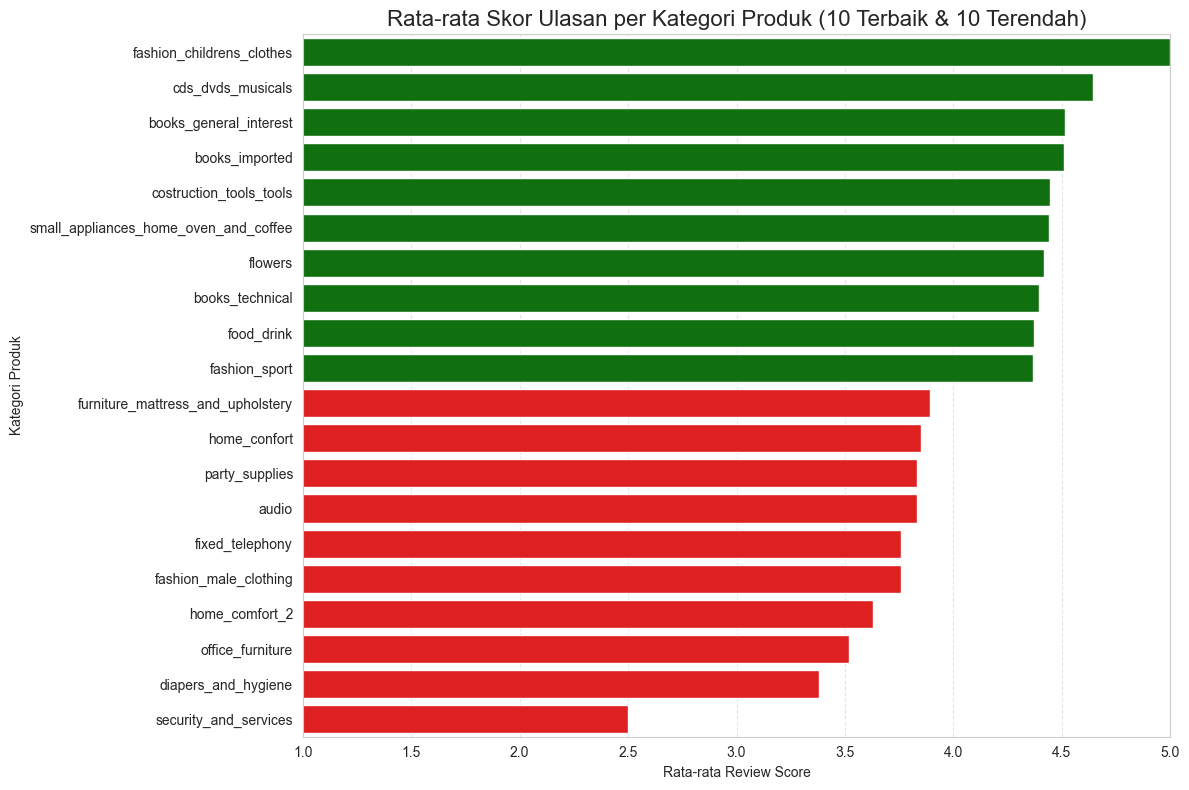

In [10]:
# Siapkan data untuk visualisasi gabungan (top 10 dan bottom 10)
plot_data = pd.concat([top_categories, bottom_categories]).drop_duplicates()
plot_data = plot_data.sort_values('avg_review_score', ascending=False)

plt.figure(figsize=(12, 8))
colors = ['green' if x in top_categories['product_category_name_english'].values else 'red' 
          for x in plot_data['product_category_name_english']]
sns.barplot(data=plot_data, y='product_category_name_english', x='avg_review_score', palette=colors)
plt.title('Rata-rata Skor Ulasan per Kategori Produk (10 Terbaik & 10 Terendah)', fontsize=16)
plt.xlabel('Rata-rata Review Score')
plt.ylabel('Kategori Produk')
plt.xlim(1, 5)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

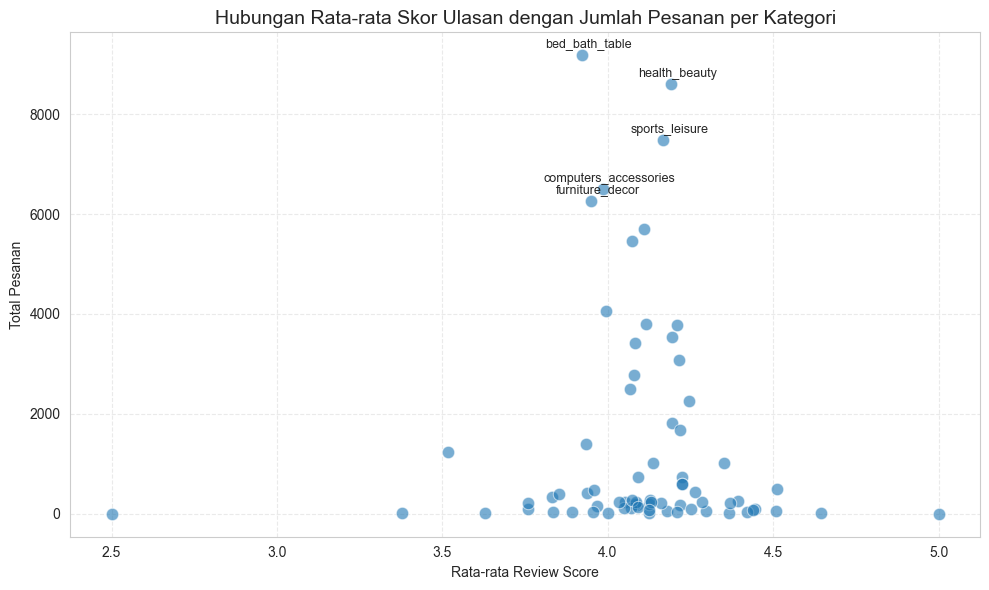

In [11]:
# Visualisasi hubungan antara skor ulasan dan jumlah pesanan
plt.figure(figsize=(10, 6))
sns.scatterplot(data=category_stats, x='avg_review_score', y='total_orders', 
                alpha=0.6, s=80)
plt.title('Hubungan Rata-rata Skor Ulasan dengan Jumlah Pesanan per Kategori', fontsize=14)
plt.xlabel('Rata-rata Review Score')
plt.ylabel('Total Pesanan')
plt.grid(True, linestyle='--', alpha=0.4)

# Tambahkan anotasi untuk kategori dengan pesanan terbanyak
top_orders = category_stats.nlargest(5, 'total_orders')
for _, row in top_orders.iterrows():
    plt.annotate(row['product_category_name_english'], 
                 (row['avg_review_score'], row['total_orders']),
                 textcoords="offset points", xytext=(5,5), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- Kategori **health_beauty** dan **sports_leisure** memiliki skor ulasan tertinggi (>4.2).  
- Kategori **bed_bath_table**, **computers_accessories**, dan **furniture_decor** memiliki skor terendah (<4.0).  
- Kategori dengan skor tinggi tidak selalu memiliki pesanan terbanyak, tetapi kategori dengan skor lebih rendah cenderung memiliki volume pesanan yang lebih banyak.

## Analisis Lanjutan (Opsional)

In [12]:
# Menghitung Recency, Frequency, Monetary per customer
import datetime as dt

# Tentukan tanggal referensi (sehari setelah transaksi terakhir)
snapshot_date = orders_revenue['order_purchase_timestamp'].max() + dt.timedelta(days=1)

rfm = orders_revenue.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,  # Recency
    'order_id': 'nunique',                                                 # Frequency
    'payment_value': 'sum'                                                 # Monetary
}).rename(columns={
    'order_purchase_timestamp': 'Recency',
    'order_id': 'Frequency',
    'payment_value': 'Monetary'
})

print(rfm.head())

                                  Recency  Frequency  Monetary
customer_id                                                   
00012a2ce6f8dcda20d059ce98491703      288          1    114.74
000161a058600d5901f007fab4c27140      410          1     67.41
0001fd6190edaaf884bcaf3d49edf079      548          1    195.42
0002414f95344307404f0ace7a26f1d5      379          1    179.35
000379cdec625522490c315e70c7a9fb      150          1    107.01


In [13]:
# Segmentasi sederhana berdasarkan kuartil
rfm['R_quartile'] = pd.qcut(rfm['Recency'], 4, labels=['4', '3', '2', '1'])
rfm['F_quartile'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=['1', '2', '3', '4'])
rfm['M_quartile'] = pd.qcut(rfm['Monetary'], 4, labels=['1', '2', '3', '4'])

rfm['RFM_Score'] = rfm['R_quartile'].astype(str) + rfm['F_quartile'].astype(str) + rfm['M_quartile'].astype(str)

# Tampilkan segmen teratas
rfm.groupby('RFM_Score').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(1).head(10)

Recency Frequency Monetary      
             mean      mean     mean count
RFM_Score                                 
111         455.6       1.0     42.8  1551
112         446.9       1.0     82.3  1560
113         454.8       1.0    135.8  1383
114         455.6       1.0    398.8  1464
121         460.2       1.0     43.1  1503
122         450.3       1.0     81.3  1500
123         451.9       1.0    136.5  1459
124         458.5       1.0    378.3  1503
131         455.6       1.0     43.6  1582
132         451.0       1.0     81.7  1592

In [14]:
# Export semua dataframe ke CSV
import os

# Buat folder output jika belum ada
output_folder = 'data'
if not os.path.exists(output_folder):
    os.makedirs(output_folder)
    print(f"Folder '{output_folder}' berhasil dibuat.")

# Daftar dataframe yang akan diekspor
dataframes_to_export = {
    'monthly_revenue.csv': monthly_revenue,
    'orders_revenue.csv': orders_revenue,
    'order_payments_grouped.csv': order_payments_grouped,
    'category_stats.csv': category_stats,
    'top_categories.csv': top_categories,
    'bottom_categories.csv': bottom_categories,
    'orders_products_reviews.csv': orders_products_reviews,
    'rfm_analysis.csv': rfm
}

# Ekspor setiap dataframe
for filename, df in dataframes_to_export.items():
    filepath = os.path.join(output_folder, filename)
    df.to_csv(filepath, index=False, encoding='utf-8')
    print(f"✓ {filename} ({len(df)} baris) - berhasil diekspor ke '{filepath}'")

✓ monthly_revenue.csv (22 baris) - berhasil diekspor ke 'data\monthly_revenue.csv'
✓ orders_revenue.csv (96477 baris) - berhasil diekspor ke 'data\orders_revenue.csv'
✓ order_payments_grouped.csv (99440 baris) - berhasil diekspor ke 'data\order_payments_grouped.csv'
✓ category_stats.csv (72 baris) - berhasil diekspor ke 'data\category_stats.csv'
✓ top_categories.csv (10 baris) - berhasil diekspor ke 'data\top_categories.csv'
✓ bottom_categories.csv (10 baris) - berhasil diekspor ke 'data\bottom_categories.csv'
✓ orders_products_reviews.csv (110013 baris) - berhasil diekspor ke 'data\orders_products_reviews.csv'
✓ rfm_analysis.csv (96477 baris) - berhasil diekspor ke 'data\rfm_analysis.csv'


**Insight:**
- Semua segmen RFM menunjukkan Frequency sebanyak 1.0, yang artinya mayoritas pelanggan hanya melakukan **satu kali pembelian**. Ini mengindikasikan **tingkat aksi pembelian yang sangat rendah** dan menjadi kekhawatiran utama untuk retensi pelanggan.
- Nilai Recency berkisar 446-460 hari, yang menunjukkan bahwa mayoritas pelanggan **sudah lama tidak berbelanja** (tidak aktif selama ±15 bulan). Ini menjadi indikasi bahwa pelanggan tidak kembali setelah pembelian pertama mereka.
- Meskipun banyak pelanggan yang hanya membeli sekali, ada variasi nilai transaksi dari 40 hingga 400. Segmen dengan monetary tinggi (114, 124) menunjukkan adanya pelanggan yang melakukan transaksi besar meskipun hanya sekali.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Tren Pendapatan Bulanan 2016–2018
    - Pendapatan bulanan menunjukkan pertumbuhan yang sangat signifikan dari awal kemunculan di Oktober 2016 hingga puncaknya pada November 2017 (1,1 juta).
    - Setelah November 2017, terjadi penurunan tajam, namun tren kembali pulih dan stabil di kisaran 1 juta sepanjang 2018.
    - Fluktuasi musiman sangat jelas, terutama lonjakan di bulan November (karena adanya Black Friday) dan penurunan pasca-promosi besar.
    - Data awal (Oktober–Desember 2016) masih sangat kecil karena platform baru beroperasi secara terbatas.
- **Conclusion pertanyaan 2:** Ulasan per Kategori
    - Kategori seperti **health_beauty** dan **sports_leisure** mendapatkan ulasan sangat baik (skor >4.2) meskipun volume penjualannya tidak selalu tertinggi.
    - Kategori dengan ulasan rendah (seperti **computers_accessories** dan **furniture_decor**) memiliki volume pesanan yang relatif kecil, menunjukkan potensi kehilangan pelanggan akibat kualitas yang kurang memuaskan.
    - Tidak terdapat korelasi kuat antara skor ulasan dan jumlah pesanan, namun kategori dengan ulasan buruk jelas perlu adanya perbaikan.

**Rekomendasi Action Item:**
- **Optimalkan Promosi Musiman:**
    - Siapkan inventori dan kampanye pemasaran maksimal menjelang November untuk memanfaatkan efek *Black Friday*.
    - Evaluasi penurunan pasca‑November (seperti pada Desember 2017) dengan meningkatkan retensi pelanggan melalui program loyalitas.
- **Perbaiki Kualitas Kategori Bermasalah:**
    - Lakukan audit produk pada kategori dengan skor ulasan rendah (skor <4.0).
    - Berikan pelatihan kepada penjual (*sellers*) di kategori tersebut atau pertimbangkan kualitas produk yang lebih ketat.
- **Manfaatkan Wawasan Ulasan untuk Pemasaran:**
    - Gunakan ulasan positif dari kategori unggulan sebagai konten testimoni di halaman produk.
    - Tawarkan rekomendasi produk dari kategori dengan skor tinggi kepada pelanggan baru.
- **Implementasi Strategi Retensi Berbasis RFM:**
    - Kirimkan penawaran khusus (diskon, gratis ongkir) kepada segmen pelanggan bernilai tinggi yang sudah lama tidak bertransaksi (skor '114').